# Calcul de trajet Métro TCL — Jour paramétrable

Modifiez **uniquement la cellule Paramètres** pour changer la date, l'heure ou les coordonnées.

Les temps d'attente sont calculés à partir d'un **lundi de référence fixe** (2026-06-01) : pour chaque ligne et chaque heure, on compte le nombre de passages réels et on en déduit l'intervalle moyen.

In [ ]:
import pandas as pd
import networkx as nx
import math
from collections import defaultdict

## 1. Paramètres — modifiez ici

In [ ]:
# ─── DATE & HEURE ─────────────────────────────────────────────────────────────
DATE_CIBLE   = "2026-06-02"   # YYYY-MM-DD
HEURE_DEPART = "08:15"        # HH:MM

# ─── COORDONNÉES GPS ──────────────────────────────────────────────────────────
LAT_A, LON_A = 45.7676, 4.8344    # Point de départ  (ex : Place Bellecour)
LAT_B, LON_B = 45.7601, 4.8594    # Point d'arrivée  (ex : Gare Part-Dieu)

# ─── CONSTANTES ───────────────────────────────────────────────────────────────
WALKING_SPEED_KMH     = 4.0
WALKING_SPEED_MS      = WALKING_SPEED_KMH * 1000 / 3600
WALKING_DETOUR_FACTOR = 1.3   # coefficient de détour rues vs vol d'oiseau (fallback)
TRANSFER_WALK_SECONDS = 90
METRO_ROUTE_IDS       = {"A", "B", "C", "D"}   # lignes métro (filtrées par route_id)
TRAM_ROUTE_TYPE       = 0                        # trams = route_type 0 (standard GTFS)
REFERENCE_MONDAY      = "2026-06-01"   # lundi de référence pour les temps d'attente

# Dérivation automatique du jour
_date_ts  = pd.Timestamp(DATE_CIBLE)
_day_name = ["monday","tuesday","wednesday","thursday","friday","saturday","sunday"][_date_ts.weekday()]
print(f"Date cible : {DATE_CIBLE} ({_day_name}) | Départ : {HEURE_DEPART}")

Date cible : 2026-06-02 (tuesday) | Départ : 08:15


## 2. Chargement des données GTFS

In [ ]:
stop_times     = pd.read_csv("/content/stop_times.txt")
trips          = pd.read_csv("/content/trips.txt")
routes         = pd.read_csv("/content/routes.txt")
stops          = pd.read_csv("/content/stops.txt")
calendar       = pd.read_csv("/content/calendar.txt")
calendar_dates = pd.read_csv("/content/calendar_dates.txt")

calendar["start_date"]    = pd.to_datetime(calendar["start_date"].astype(str), format="%Y%m%d")
calendar["end_date"]      = pd.to_datetime(calendar["end_date"].astype(str),   format="%Y%m%d")
calendar_dates["date"]    = pd.to_datetime(calendar_dates["date"].astype(str), format="%Y%m%d")
stops["stop_id"]          = stops["stop_id"].astype(str)
stop_times["stop_id"]     = stop_times["stop_id"].astype(str)
print("Données GTFS chargées.")

/tmp/ipykernel_4209/2094031118.py:2: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  trips          = pd.read_csv("/content/trips.txt")


Données GTFS chargées.


## 3. Fonctions utilitaires

In [ ]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6_371_000
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    a = math.sin(math.radians(lat2-lat1)/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(math.radians(lon2-lon1)/2)**2
    return R * 2 * math.asin(math.sqrt(a))

def walking_time_seconds(dist_m):
    """Temps de marche en secondes : distance à vol d'oiseau x coefficient de détour."""
    return (dist_m * WALKING_DETOUR_FACTOR) / WALKING_SPEED_MS

def format_duration(s):
    s = int(s); m, sec = divmod(s, 60)
    return f"{sec} sec" if m == 0 else f"{m} min {sec} sec"

def to_seconds(t):
    """HH:MM:SS -> secondes (supporte les heures GTFS > 24)."""
    h, m, s = map(int, str(t).split(":"))
    return h*3600 + m*60 + s

def seconds_to_hhmm(s):
    s = int(s); h, r = divmod(s, 3600)
    return f"{h:02d}:{r//60:02d}"

def get_active_services(calendar_df, calendar_dates_df, date_str):
    """Retourne les service_id actifs pour une date donnée (calendrier + exceptions GTFS)."""
    date_ts = pd.Timestamp(date_str)
    day_col = ["monday","tuesday","wednesday","thursday","friday","saturday","sunday"][date_ts.weekday()]
    active  = set(calendar_df[
        (calendar_df[day_col] == 1) &
        (calendar_df["start_date"] <= date_ts) &
        (calendar_df["end_date"]   >= date_ts)
    ]["service_id"])
    exc     = calendar_dates_df[calendar_dates_df["date"] == date_ts]
    active -= set(exc[exc["exception_type"] == 2]["service_id"])
    active |= set(exc[exc["exception_type"] == 1]["service_id"])
    return active

## 4. Temps d'attente moyens par ligne et par heure (lundi de référence)

Pour chaque ligne et chaque tranche horaire, on compte les départs de trains sur le lundi de référence.
Chaque ligne ayant **2 directions**, on divise par 2 pour n'obtenir que les trains allant dans un sens donné.

```
attente_moyenne(ligne, heure) = 3600 / (nb_passages / 2)
```

In [ ]:
def build_avg_wait(stop_times_df, trips_df, calendar_df, calendar_dates_df,
                   reference_monday, metro_route_ids):
    """
    Calcule le temps d'attente moyen en secondes par (ligne, heure)
    à partir du lundi de référence.

    Retourne un dict : (route_id, heure_int) -> attente_secondes
    heure_int est un entier 0..23 (l'heure à laquelle on arrive en station).

    Les trips GTFS incluent les deux directions (terminus A -> terminus B et retour).
    On divise donc le nombre de passages par 2 pour obtenir la fréquence par direction.
    """
    # Services actifs le lundi de référence
    active_svc = get_active_services(calendar_df, calendar_dates_df, reference_monday)

    # Trips métro actifs ce jour
    ref_trips = trips_df[
        trips_df["route_id"].isin(metro_route_ids) &
        trips_df["service_id"].isin(active_svc)
    ][["trip_id", "route_id"]]

    # On prend uniquement le premier arrêt de chaque trip (stop_sequence == 1)
    # = l'heure de départ du train depuis son terminus
    first_stops = stop_times_df[
        stop_times_df["stop_sequence"] == 1
    ][["trip_id", "departure_time"]].copy()

    first_stops = first_stops.merge(ref_trips, on="trip_id", how="inner")

    # Extraction de l'heure (modulo 24 pour les heures GTFS > 23)
    first_stops["heure"] = first_stops["departure_time"].apply(
        lambda t: int(str(t).split(":")[0]) % 24
    )

    # Comptage des passages par (ligne, heure)
    counts = (
        first_stops
        .groupby(["route_id", "heure"])
        .size()
        .reset_index(name="nb_passages")
    )

    # Division par 2 : chaque ligne a 2 directions, on veut la fréquence par sens
    # Intervalle entre deux trains = 3600 / (nb_passages / 2)
    # Attente moyenne = intervalle / 2  (on arrive en moyenne à mi-intervalle)
    # Si aucun passage dans un créneau -> on met 1800 s (prudence)
    avg_wait = {}
    for _, row in counts.iterrows():
        nb_par_sens = row["nb_passages"] / 2
        intervalle  = 3600 / nb_par_sens
        avg_wait[(row["route_id"], int(row["heure"]))] = intervalle / 2

    return avg_wait


def get_wait(avg_wait, route_id, clock_seconds, fallback_s=1800):
    """
    Retourne le temps d'attente moyen (en secondes) pour une ligne
    à l'heure correspondant à clock_seconds.
    """
    heure = (int(clock_seconds) // 3600) % 24
    return avg_wait.get((route_id, heure), fallback_s)


# Pré-calcul une seule fois (métro + tram)
# On construit d'abord l'ensemble des route_id à inclure
tram_route_ids = set(routes[routes["route_type"] == TRAM_ROUTE_TYPE]["route_id"])
all_route_ids  = METRO_ROUTE_IDS | tram_route_ids

avg_wait = build_avg_wait(stop_times, trips, calendar, calendar_dates,
                          REFERENCE_MONDAY, all_route_ids)

# Aperçu : attentes moyennes pour la ligne A
print("Ligne A — attente moyenne par heure :")
for h in range(5, 24):
    w = avg_wait.get(("A", h))
    if w:
        print(f"  {h:02d}h : {format_duration(w)} ({w:.0f}s)")
print(f"\n{len(tram_route_ids)} lignes de tram incluses : {sorted(tram_route_ids)}")

Ligne A — attente moyenne par heure :
  05h : 4 min 0 sec (240s)
  06h : 2 min 8 sec (129s)
  07h : 1 min 27 sec (88s)
  08h : 1 min 25 sec (86s)
  09h : 1 min 52 sec (112s)
  10h : 2 min 30 sec (150s)
  11h : 2 min 8 sec (129s)
  12h : 1 min 52 sec (112s)
  13h : 1 min 49 sec (109s)
  14h : 1 min 52 sec (112s)
  15h : 1 min 52 sec (112s)
  16h : 1 min 30 sec (90s)
  17h : 1 min 27 sec (88s)
  18h : 1 min 27 sec (88s)
  19h : 1 min 30 sec (90s)
  20h : 2 min 24 sec (144s)
  21h : 3 min 45 sec (225s)
  22h : 4 min 17 sec (257s)
  23h : 4 min 0 sec (240s)

9 lignes de tram incluses : ['RX', 'T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'TS']


## 5. Services et graphe pour la date cible

In [ ]:
# Services actifs pour DATE_CIBLE
active_services = get_active_services(calendar, calendar_dates, DATE_CIBLE)

# Trips métro + tram actifs ce jour
network_trips        = trips[trips["route_id"].isin(all_route_ids)]
active_network_trips = network_trips[network_trips["service_id"].isin(active_services)]

# Stop times filtrés
metro_stop_times = stop_times[stop_times["trip_id"].isin(active_network_trips["trip_id"])].copy()
metro_stop_times = metro_stop_times.sort_values(["trip_id", "stop_sequence"])
metro_stop_times = metro_stop_times.merge(trips[["trip_id", "route_id"]], on="trip_id", how="inner")
metro_stops      = stops[stops["stop_id"].isin(metro_stop_times["stop_id"])].drop_duplicates(subset="stop_id").copy()

print(f"{len(active_services)} services actifs | {len(active_network_trips)} trips (métro + tram) | {len(metro_stops)} stations")

# Graphe brut par stop_id
G = nx.Graph()
for _, s in metro_stops.iterrows():
    G.add_node(s["stop_id"], name=s["stop_name"], lat=float(s["stop_lat"]), lon=float(s["stop_lon"]))
for trip_id, grp in metro_stop_times.sort_values(["trip_id","stop_sequence"]).groupby("trip_id"):
    sids, route = grp["stop_id"].tolist(), grp["route_id"].iloc[0]
    for i in range(len(sids)-1):
        G.add_edge(sids[i], sids[i+1], route=route)

# Fusion par nom de station
name_to_node = {}
G2 = nx.Graph()
for node, data in G.nodes(data=True):
    if data["name"] not in name_to_node:
        name_to_node[data["name"]] = node
        G2.add_node(node, **data)
for u, v, data in G.edges(data=True):
    u2, v2 = name_to_node[G.nodes[u]["name"]], name_to_node[G.nodes[v]["name"]]
    if u2 != v2:
        G2.add_edge(u2, v2, **data)

print(f"Graphe : {G2.number_of_nodes()} stations, {G2.number_of_edges()} arêtes")

933 services actifs | 4490 trips (métro + tram) | 336 stations
Graphe : 145 stations, 162 arêtes


## 6. Graphe pondéré (temps médian entre stations)

In [ ]:
def build_weighted_graph(G2_in, mst, stops_df):
    """Graphe pondéré : poids = temps médian de parcours entre deux stations voisines."""
    col      = "departure_time" if "departure_time" in mst.columns else "arrival_time"
    sid2name = stops_df.set_index("stop_id")["stop_name"].to_dict()
    edge_data = defaultdict(lambda: defaultdict(list))

    for _, grp in mst.sort_values(["trip_id","stop_sequence"]).groupby("trip_id"):
        sids, times, route = grp["stop_id"].tolist(), grp[col].tolist(), grp["route_id"].iloc[0]
        for i in range(len(sids)-1):
            n1, n2 = sid2name.get(str(sids[i])), sid2name.get(str(sids[i+1]))
            if not n1 or not n2 or n1 == n2: continue
            t1, t2 = to_seconds(times[i]), to_seconds(times[i+1])
            if t2 > t1: edge_data[(n1,n2)][route].append(t2-t1)

    n2n = {data["name"]: node for node, data in G2_in.nodes(data=True)}
    Gw  = nx.Graph()
    for node, data in G2_in.nodes(data=True): Gw.add_node(node, **data)

    for (n1,n2), rd in edge_data.items():
        if n1 not in n2n or n2 not in n2n: continue
        u, v  = n2n[n1], n2n[n2]
        durs  = [d for ds in rd.values() for d in ds]
        med_t = sorted(durs)[len(durs)//2]
        rset  = set(rd.keys())
        if Gw.has_edge(u,v):
            Gw[u][v]["weight"] = min(Gw[u][v]["weight"], med_t)
            Gw[u][v]["routes"] |= rset
        else:
            Gw.add_edge(u, v, weight=med_t, routes=rset)
    return Gw


G2_weighted = build_weighted_graph(G2, metro_stop_times, metro_stops)
print("Graphe pondéré construit.")

Graphe pondéré construit.


## 7. Calcul du trajet A → B

In [ ]:
def nearest_station(lat, lon, graph):
    best, dist = None, float("inf")
    for node, data in graph.nodes(data=True):
        d = haversine(lat, lon, data["lat"], data["lon"])
        if d < dist: dist, best = d, node
    return best, dist


def nearest_stations(lat, lon, graph, n=5):
    """Retourne les n stations les plus proches avec leurs distances."""
    dists = [(haversine(lat, lon, data["lat"], data["lon"]), node)
             for node, data in graph.nodes(data=True)]
    return sorted(dists)[:n]


def dijkstra_with_wait(graph, source, target, clock_start, avg_wait):
    """
    Dijkstra sur états (node, route).

    Un état = (station, ligne_courante). On ne finalise un état qu'une seule fois,
    mais un même nœud physique peut être visité via plusieurs lignes différentes.
    Cela garantit que le chemin optimal global est toujours trouvé,
    même quand une ligne moins fréquente offre un trajet plus court
    grâce à moins de correspondances.

    Les cycles sont évités par best_cost : on ne remet un état dans le heap
    que si on a trouvé un coût strictement inférieur.
    """
    import heapq

    counter   = 0
    heap      = [(0, counter, source, None)]
    visited   = set()          # états (node, route) déjà finalisés
    best_cost = {}             # (node, route) -> meilleur coût vu
    parent    = {}             # (node, route) -> (node_parent, route_parent)

    while heap:
        cost, _, node, cur_route = heapq.heappop(heap)

        state = (node, cur_route)
        if state in visited:
            continue
        visited.add(state)

        if node == target:
            path  = []
            s     = state
            while s in parent:
                path.append(s)
                s = parent[s]
            path.append((source, None))
            path.reverse()
            return cost, path

        clock_here = clock_start + cost

        for neighbor in graph.neighbors(node):
            edge_routes = graph[node][neighbor].get("routes", set())
            edge_weight = graph[node][neighbor].get("weight", float("inf"))

            for route in edge_routes:
                new_state = (neighbor, route)
                if new_state in visited:
                    continue

                if cur_route is None:
                    # Premier embarquement
                    wait       = get_wait(avg_wait, route, clock_here)
                    transition = wait + edge_weight
                elif route == cur_route:
                    # Même ligne : pas d'attente
                    transition = edge_weight
                else:
                    # Changement de ligne : marche + attente de la nouvelle ligne
                    wait       = get_wait(avg_wait, route, clock_here)
                    transition = TRANSFER_WALK_SECONDS + wait + edge_weight

                new_cost = cost + transition

                if new_cost < best_cost.get(new_state, float("inf")):
                    best_cost[new_state] = new_cost
                    parent[new_state]    = (node, cur_route)
                    counter += 1
                    heapq.heappush(heap, (new_cost, counter, neighbor, route))

    return float("inf"), []


def compute_total_travel_time(lat_a, lon_a, lat_b, lon_b,
                               departure_hhmm, graph, avg_wait, n_candidates=10):
    """
    Calcule le trajet complet A -> B avec Dijkstra sur états (station, ligne).
    Teste les n_candidates stations les plus proches au départ ET à l'arrivée
    pour trouver le trajet total le plus court — crucial quand une ligne est fermée
    et que la station la plus proche n'est plus accessible.
    """
    h, m     = map(int, departure_hhmm.split(":"))
    depart_s = h*3600 + m*60

    dep_candidates = nearest_stations(lat_a, lon_a, graph, n=n_candidates)
    arr_candidates = nearest_stations(lat_b, lon_b, graph, n=n_candidates)

    best_result = None

    for dd, nd in dep_candidates:
        walk_dep_s = walking_time_seconds(dd)
        clock      = depart_s + walk_dep_s

        for da, na in arr_candidates:
            walk_arr_s = walking_time_seconds(da)

            if nd == na:
                total_s = walk_dep_s + walk_arr_s
                result  = {
                    "date": DATE_CIBLE, "jour": _day_name, "depart_hhmm": departure_hhmm,
                    "station_depart":        graph.nodes[nd]["name"],
                    "station_arrivee":       graph.nodes[na]["name"],
                    "dist_marche_dep_m":     round(dd, 1),
                    "temps_marche_dep_s":    round(walk_dep_s),
                    "heure_arrivee_station": seconds_to_hhmm(clock),
                    "ligne_depart": None, "temps_attente_dep_s": 0,
                    "chemin_metro": [graph.nodes[nd]["name"]], "nb_stations": 0, "temps_metro_s": 0,
                    "correspondances": [],
                    "dist_marche_arr_m":  round(da, 1),
                    "temps_marche_arr_s": round(walk_arr_s),
                    "temps_total_s":      round(total_s),
                    "heure_arrivee_B":    seconds_to_hhmm(depart_s + total_s),
                    "mode": "tc",
                }
            else:
                ride_cost, state_path = dijkstra_with_wait(graph, nd, na, clock, avg_wait)

                if ride_cost == float("inf"):
                    continue

                node_path   = [s[0] for s in state_path]
                route_path  = [s[1] for s in state_path]
                first_route = route_path[1] if len(route_path) > 1 else None
                wait_dep_s  = get_wait(avg_wait, first_route, clock) if first_route else 0

                tdetail  = []
                run_cost = 0
                clock2   = clock + wait_dep_s
                for i in range(1, len(state_path)):
                    prev_node, prev_route = state_path[i-1]
                    cur_node,  cur_route  = state_path[i]
                    edge_w = graph[prev_node][cur_node].get("weight", 0)
                    if prev_route is not None and cur_route != prev_route:
                        arr_tr  = clock2 + run_cost
                        wait_tr = get_wait(avg_wait, cur_route, arr_tr + TRANSFER_WALK_SECONDS)
                        tdetail.append({
                            "station":          graph.nodes[prev_node]["name"],
                            "ligne_quittee":    prev_route,
                            "ligne_prise":      cur_route,
                            "heure_arrivee":    seconds_to_hhmm(arr_tr),
                            "marche_station_s": TRANSFER_WALK_SECONDS,
                            "attente_s":        round(wait_tr),
                        })
                        run_cost += TRANSFER_WALK_SECONDS + wait_tr
                    run_cost += edge_w

                total_s = walk_dep_s + ride_cost + walk_arr_s
                result  = {
                    "date":                  DATE_CIBLE,
                    "jour":                  _day_name,
                    "depart_hhmm":           departure_hhmm,
                    "station_depart":        graph.nodes[nd]["name"],
                    "station_arrivee":       graph.nodes[na]["name"],
                    "dist_marche_dep_m":     round(dd, 1),
                    "temps_marche_dep_s":    round(walk_dep_s),
                    "heure_arrivee_station": seconds_to_hhmm(clock),
                    "ligne_depart":          first_route,
                    "temps_attente_dep_s":   round(wait_dep_s),
                    "chemin_metro":          [graph.nodes[n]["name"] for n in node_path],
                    "nb_stations":           len(node_path) - 1,
                    "temps_metro_s":         round(ride_cost),
                    "correspondances":       tdetail,
                    "dist_marche_arr_m":     round(da, 1),
                    "temps_marche_arr_s":    round(walk_arr_s),
                    "temps_total_s":         round(total_s),
                    "heure_arrivee_B":       seconds_to_hhmm(depart_s + total_s),
                    "mode":                  "tc",
                }

            if best_result is None or result["temps_total_s"] < best_result["temps_total_s"]:
                best_result = result

    # Fallback : aucun chemin TC trouvé → marche directe A→B
    if best_result is None:
        dist_directe = haversine(lat_a, lon_a, lat_b, lon_b)
        walk_total   = walking_time_seconds(dist_directe * WALKING_DETOUR_FACTOR)
        return {
            "date": DATE_CIBLE, "jour": _day_name, "depart_hhmm": departure_hhmm,
            "station_depart": "—", "station_arrivee": "—",
            "dist_marche_dep_m": 0, "temps_marche_dep_s": 0,
            "heure_arrivee_station": departure_hhmm,
            "ligne_depart": None, "temps_attente_dep_s": 0,
            "chemin_metro": [], "nb_stations": 0, "temps_metro_s": 0,
            "correspondances": [],
            "dist_marche_arr_m": 0, "temps_marche_arr_s": round(walk_total),
            "temps_total_s": round(walk_total),
            "heure_arrivee_B": seconds_to_hhmm(depart_s + walk_total),
            "mode": "marche",
        }

    return best_result


def print_trajet(r):
    if "error" in r:
        print("Erreur :", r["error"]); return
    sep = "=" * 60
    print(sep)
    print("  ITINERAIRE A -> B")
    print(f"  Date : {r['date']} ({r['jour']})")
    print(sep)
    print(f"  Depart            : {r['depart_hhmm']}")

    if r.get("mode") == "marche":
        print(f"  ⚠ Aucun TC disponible — trajet entièrement à pied")
        print(f"  Marche directe    : {format_duration(r['temps_total_s'])}")
        print(f"  TOTAL             : {format_duration(r['temps_total_s'])}")
        print(f"  Arrivee estimee   : {r['heure_arrivee_B']}")
        print(sep)
        return

    print(f"  Marche vers       : {r['station_depart']} ({r['dist_marche_dep_m']} m, {format_duration(r['temps_marche_dep_s'])})")
    print(f"  Arrivee station   : {r['heure_arrivee_station']}")
    print(f"  Ligne prise       : {r['ligne_depart']}")
    print(f"  Attente moyenne   : {format_duration(r['temps_attente_dep_s'])}")
    print()
    print(f"  Trajet           : {' -> '.join(r['chemin_metro'])}")
    print(f"  Nb arrets        : {r['nb_stations']}")
    for i, c in enumerate(r["correspondances"], 1):
        print(f"  Correspondance {i} : {c['station']} (ligne {c['ligne_quittee']} -> {c['ligne_prise']})")
        print(f"    Arrivee: {c['heure_arrivee']} | Marche: {format_duration(c['marche_station_s'])} | Attente ligne {c['ligne_prise']}: {format_duration(c['attente_s'])}")
    print()
    print(f"  Marche finale    : {r['dist_marche_arr_m']} m ({format_duration(r['temps_marche_arr_s'])})")
    print(f"  TOTAL            : {format_duration(r['temps_total_s'])}")
    print(f"  Arrivee estimee  : {r['heure_arrivee_B']}")
    print(sep)



def fermer_ligne(graph, ligne):
    """
    Retourne une copie du graphe sans la ligne donnée.
    - Si une arête n'a que cette ligne : elle est supprimée
    - Si une arête a plusieurs lignes : on retire juste cette ligne
    - Les nœuds qui n'ont plus aucune arête sont supprimés
    """
    G_ferme = graph.copy()
    edges_to_remove = []

    for u, v, d in G_ferme.edges(data=True):
        routes = d.get("routes", set()) - {ligne}
        if not routes:
            edges_to_remove.append((u, v))
        else:
            G_ferme[u][v]["routes"] = routes

    G_ferme.remove_edges_from(edges_to_remove)

    # Supprimer les nœuds isolés (plus aucune arête = inaccessibles)
    noeuds_isoles = [n for n, deg in G_ferme.degree() if deg == 0]
    G_ferme.remove_nodes_from(noeuds_isoles)
    return G_ferme

## 8. Lancement du calcul

In [ ]:
result = compute_total_travel_time(
    LAT_A, LON_A, LAT_B, LON_B,
    HEURE_DEPART,
    G2_weighted, avg_wait
)
print_trajet(result)

  ITINERAIRE A -> B
  Date : 2026-06-02 (tuesday)
  Depart            : 08:15
  Marche vers       : Hôtel de Ville L. Pradel (134.4 m, 2 min 37 sec)
  Arrivee station   : 08:17
  Ligne prise       : A
  Attente moyenne   : 1 min 26 sec

  Trajet           : Hôtel de Ville L. Pradel -> Foch -> Masséna -> Charpennes Charles Hernu -> Brotteaux -> Gare Part-Dieu V.Merle
  Nb arrets        : 5
  Correspondance 1 : Charpennes Charles Hernu (ligne A -> B)
    Arrivee: 08:23 | Marche: 1 min 30 sec | Attente ligne B: 1 min 2 sec

  Marche finale    : 217.6 m (4 min 15 sec)
  TOTAL            : 18 min 7 sec
  Arrivee estimee  : 08:33


## 9. Impact de la fermeture d'une ligne

Pour chaque ligne, on calcule le surcoût en temps pour chaque paire OD.
Au-delà de **15 minutes** de surcoût, on considère que l'usager bascule probablement vers un autre mode (voiture).

In [ ]:
import time


# ─── PARAMÈTRES ───────────────────────────────────────────────────────────────
HEURE_IMPACT       = "08:15"
SEUIL_REPORT_MODAL = 15 * 60   # secondes — au-delà : report probable vers voiture
SEUIL_IMPACTE      = 60        # secondes — au-delà : impacté mais reste en TCL

# ─── PAIRES OD MANUELLES ──────────────────────────────────────────────────────
# Format : (origine, destination, nb_individus)
od_df_manuel = [
    # ─── BANLIEUE → CENTRE (flux domicile-travail) ────────────────────────────
    ("Vaulx-en-Velin La Soie",   "Bellecour",                 86),   # T3 → A, axe est-centre
    ("Vaulx-en-Velin La Soie",   "Hôtel de Ville L. Pradel",  73),   # T3 → A, est-centre
    ("Gare de Vénissieux",       "Bellecour",                 72),   # B, axe sud-centre
    ("Gare de Vénissieux",       "Saxe - Gambetta",           60),   # B, sud vers Part-Dieu
    ("Meyzieu Z.i.",             "Gare Part-Dieu V.Merle",    65),   # T3, est vers Part-Dieu
    ("Décines Centre",           "Gare Part-Dieu Villette",   54),   # T3, est vers Part-Dieu

    # ─── CORRESPONDANCES MAJEURES ─────────────────────────────────────────────
    ("Perrache",                 "Charpennes Charles Hernu",  80),   # A, axe nord-sud
    ("Perrache",                 "Gare Part-Dieu V.Merle",    91),   # A+B, les deux gares
    ("Gorge de Loup",            "Bellecour",                 54),   # D, ouest-centre
    ("Vieux Lyon Cat. St-Jean",  "Bellecour",                 52),   # D, rive droite-centre

    # ─── INTRA-CENTRE / PÔLES D'ACTIVITÉ ─────────────────────────────────────
    ("Bellecour",                "Gare Part-Dieu V.Merle",    96),   # A+B, cœur de ville
    ("Hôtel de Ville L. Pradel", "Saxe - Gambetta",           71),   # A+B, centre-est
    ("Charpennes Charles Hernu", "Jean Macé",                  66),   # A+B, nord-sud
    ("Gratte-Ciel",              "Gare Part-Dieu Villette",   53),   # A, Villeurbanne-Part-Dieu

    # ─── PÔLES UNIVERSITAIRES / HÔPITAUX ─────────────────────────────────────
    ("La Doua - Gaston Berger",  "Bellecour",                 61),   # T1/T4, campus-centre
    ("Grange Blanche",           "Bellecour",                 67),   # D, hôpital-centre
    ("Grange Blanche",           "Gare Part-Dieu V.Merle",    53),   # D+B, hôpital-gare
]

# Coordonnées GPS de chaque station
coords = {data["name"]: (data["lat"], data["lon"])
          for _, data in G2_weighted.nodes(data=True)}

# Toutes les lignes à tester
lignes_a_tester = sorted(["A", "B", "C", "D"] + list(tram_route_ids))

# ─── CALCUL DES TEMPS NORMAUX ─────────────────────────────────────────────────
print("Calcul des temps normaux...")
od_normal = {}

for o, d, nb in od_df_manuel:
    if o not in coords or d not in coords:
        print(f"  ⚠ Station introuvable : '{o}' ou '{d}'")
        print("    Noms disponibles proches :")
        for name in coords:
            if any(mot.lower() in name.lower() for mot in (o + " " + d).split()):
                print(f"      {repr(name)}")
        continue
    lat_o, lon_o = coords[o]
    lat_d, lon_d = coords[d]
    r = compute_total_travel_time(lat_o, lon_o, lat_d, lon_d,
                                  HEURE_IMPACT, G2_weighted, avg_wait)
    od_normal[(o, d)] = {
        "temps_s":      r["temps_total_s"],
        "nb_individus": nb,
        "mode":         r.get("mode", "tc"),
    }
    print(f"  {o} → {d} : {format_duration(r['temps_total_s'])} [{r.get('mode','tc')}]")

print(f"\n{len(od_normal)} paires OD calculées\n")

# ─── BOUCLE SUR TOUTES LES LIGNES ─────────────────────────────────────────────
impacts = []

for ligne in lignes_a_tester:
    t0      = time.time()
    G_ferme = fermer_ligne(G2_weighted, ligne)

    total_pond      = 0
    total_individus = 0
    nb_report_modal = 0
    nb_impactes     = 0
    nb_non_impactes = 0
    deltas          = []

    for (o, d), info in od_normal.items():
        lat_o, lon_o = coords[o]
        lat_d, lon_d = coords[d]
        nb           = info["nb_individus"]

        r     = compute_total_travel_time(lat_o, lon_o, lat_d, lon_d,
                                          HEURE_IMPACT, G_ferme, avg_wait)
        delta = r["temps_total_s"] - info["temps_s"]

        total_pond      += delta * nb
        total_individus += nb
        deltas.append((o, d, delta, nb))

        if delta > SEUIL_REPORT_MODAL:
            nb_report_modal += nb
        elif delta > SEUIL_IMPACTE:
            nb_impactes += nb
        else:
            nb_non_impactes += nb

    tps_perdu_moy = total_pond / total_individus if total_individus > 0 else 0
    mediane       = sorted([d for _, _, d, _ in deltas])[len(deltas)//2] if deltas else 0

    impacts.append({
        "ligne":               ligne,
        "temps_perdu_moy_s":   round(tps_perdu_moy),
        "temps_perdu_moy_min": round(tps_perdu_moy / 60, 1),
        "mediane_delta_s":     round(mediane),
        "nb_report_modal":     nb_report_modal,
        "nb_impactes":         nb_impactes,
        "nb_non_impactes":     nb_non_impactes,
        "detail":              deltas,
    })

    print(f"  Ligne {ligne:3s} "
          f"| moy: {tps_perdu_moy/60:+.1f} min "
          f"| report modal: {nb_report_modal:4d} "
          f"| impactés: {nb_impactes:4d} "
          f"| {time.time()-t0:.1f}s")

# ─── RÉSULTATS GLOBAUX ────────────────────────────────────────────────────────
df_impact = pd.DataFrame(impacts).sort_values("temps_perdu_moy_s", ascending=False)

print("\n" + "="*75)
print("  CLASSEMENT DES LIGNES PAR IMPACT")
print("="*75)
print(f"{'Ligne':<8} {'Tps perdu moy':>15} {'Médiane':>10} "
      f"{'Report modal':>14} {'Impactés TC':>13}")
print("-"*75)
for _, row in df_impact.iterrows():
    print(f"{row['ligne']:<8}"
          f" {row['temps_perdu_moy_min']:>13.1f} min"
          f" {row['mediane_delta_s']/60:>8.1f} min"
          f" {row['nb_report_modal']:>14}"
          f" {row['nb_impactes']:>13}")

# ─── DÉTAIL PAR PAIRE OD ─────────────────────────────────────────────────────
print("\n" + "="*75)
print("  DÉTAIL PAR PAIRE OD")
print("="*75)
for row in impacts:
    if row["temps_perdu_moy_s"] == 0:
        continue
    print(f"\n  Sans ligne {row['ligne']} :")
    for o, d, delta, nb in row["detail"]:
        categorie = "⛔ report modal" if delta > SEUIL_REPORT_MODAL \
                    else "⚠ impacté" if delta > SEUIL_IMPACTE \
                    else "✓ ok"
        signe = "+" if delta >= 0 else ""
        print(f"    {o} → {d} ({nb} ind.) : {signe}{format_duration(delta)} {categorie}")

Calcul des temps normaux...
  Vaulx-en-Velin La Soie → Bellecour : 17 min 37 sec [tc]
  Vaulx-en-Velin La Soie → Hôtel de Ville L. Pradel : 14 min 49 sec [tc]
  Gare de Vénissieux → Bellecour : 16 min 44 sec [tc]
  Gare de Vénissieux → Saxe - Gambetta : 13 min 55 sec [tc]
  Meyzieu Z.i. → Gare Part-Dieu V.Merle : 35 min 11 sec [tc]
  Décines Centre → Gare Part-Dieu Villette : 19 min 21 sec [tc]
  Perrache → Charpennes Charles Hernu : 11 min 7 sec [tc]
  Perrache → Gare Part-Dieu V.Merle : 15 min 2 sec [tc]
  Gorge de Loup → Bellecour : 5 min 2 sec [tc]
  Vieux Lyon Cat. St-Jean → Bellecour : 2 min 35 sec [tc]
  Bellecour → Gare Part-Dieu V.Merle : 9 min 58 sec [tc]
  Hôtel de Ville L. Pradel → Saxe - Gambetta : 9 min 38 sec [tc]
  Charpennes Charles Hernu → Jean Macé : 9 min 1 sec [tc]
  Gratte-Ciel → Gare Part-Dieu Villette : 14 min 33 sec [tc]
  La Doua - Gaston Berger → Bellecour : 20 min 21 sec [tc]
  Grange Blanche → Bellecour : 9 min 36 sec [tc]
  Grange Blanche → Gare Part-Dieu 

In [ ]:
import time

# ─── PARAMÈTRES ───────────────────────────────────────────────────────────────
HEURE_IMPACT       = "08:15"
SEUIL_REPORT_MODAL = 15 * 60   # secondes — au-delà : report probable vers voiture
SEUIL_IMPACTE      = 60        # secondes — au-delà : impacté mais reste en TCL

# ─── PAIRES OD MANUELLES ──────────────────────────────────────────────────────
od_df_manuel = [
    ("Vaulx-en-Velin La Soie",   "Bellecour",                 86),
    ("Vaulx-en-Velin La Soie",   "Hôtel de Ville L. Pradel",  73),
    ("Gare de Vénissieux",       "Bellecour",                 72),
    ("Gare de Vénissieux",       "Saxe - Gambetta",           60),
    ("Meyzieu Z.i.",             "Gare Part-Dieu V.Merle",    65),
    ("Décines Centre",           "Gare Part-Dieu Villette",   54),
    ("Perrache",                 "Charpennes Charles Hernu",  80),
    ("Perrache",                 "Gare Part-Dieu V.Merle",    91),
    ("Gorge de Loup",            "Bellecour",                 54),
    ("Vieux Lyon Cat. St-Jean",  "Bellecour",                 52),
    ("Bellecour",                "Gare Part-Dieu V.Merle",    96),
    ("Hôtel de Ville L. Pradel", "Saxe - Gambetta",           71),
    ("Charpennes Charles Hernu", "Jean Macé",                  66),
    ("Gratte-Ciel",              "Gare Part-Dieu Villette",   53),
    ("La Doua - Gaston Berger",  "Bellecour",                 61),
    ("Grange Blanche",           "Bellecour",                 67),
    ("Grange Blanche",           "Gare Part-Dieu V.Merle",    53),
]

coords = {data["name"]: (data["lat"], data["lon"])
          for _, data in G2_weighted.nodes(data=True)}

lignes_a_tester = sorted(["A", "B", "C", "D"] + list(tram_route_ids))

# ─── CALCUL DES TEMPS NORMAUX ─────────────────────────────────────────────────
print("Calcul des temps normaux...")
od_normal = {}

for o, d, nb in od_df_manuel:
    if o not in coords or d not in coords:
        print(f"  ⚠ Station introuvable : '{o}' ou '{d}'")
        continue
    lat_o, lon_o = coords[o]
    lat_d, lon_d = coords[d]
    r = compute_total_travel_time(lat_o, lon_o, lat_d, lon_d,
                                  HEURE_IMPACT, G2_weighted, avg_wait)
    od_normal[(o, d)] = {
        "temps_s":      r["temps_total_s"],
        "nb_individus": nb,
        "mode":         r.get("mode", "tc"),
    }
    print(f"  {o} → {d} : {format_duration(r['temps_total_s'])} [{r.get('mode','tc')}]")

print(f"\n{len(od_normal)} paires OD calculées\n")

# ─── BOUCLE SUR TOUTES LES LIGNES ─────────────────────────────────────────────
impacts = []

for ligne in lignes_a_tester:
    t0      = time.time()
    G_ferme = fermer_ligne(G2_weighted, ligne)

    total_delta     = 0   # somme des deltas (non pondérée par nb_individus)
    nb_trajets      = 0   # nombre de paires OD
    nb_report_modal = 0   # nb de trajets (pas individus) avec delta > 15 min
    nb_impactes     = 0   # nb de trajets avec 60s < delta <= 15 min
    nb_non_impactes = 0
    deltas          = []

    for (o, d), info in od_normal.items():
        lat_o, lon_o = coords[o]
        lat_d, lon_d = coords[d]
        nb           = info["nb_individus"]

        r     = compute_total_travel_time(lat_o, lon_o, lat_d, lon_d,
                                          HEURE_IMPACT, G_ferme, avg_wait)
        delta = r["temps_total_s"] - info["temps_s"]

        # ← moyenne pondérée par trajet (pas par nb_individus)
        total_delta += delta
        nb_trajets  += 1
        deltas.append((o, d, delta, nb))

        if delta > SEUIL_REPORT_MODAL:
            nb_report_modal += 1   # ← on compte les trajets, pas les individus
        elif delta > SEUIL_IMPACTE:
            nb_impactes += 1
        else:
            nb_non_impactes += 1

    tps_perdu_moy = total_delta / nb_trajets if nb_trajets > 0 else 0
    mediane       = sorted([d for _, _, d, _ in deltas])[len(deltas)//2] if deltas else 0

    impacts.append({
        "ligne":               ligne,
        "temps_perdu_moy_s":   round(tps_perdu_moy),
        "temps_perdu_moy_min": round(tps_perdu_moy / 60, 1),
        "mediane_delta_s":     round(mediane),
        "nb_report_modal":     nb_report_modal,
        "nb_impactes":         nb_impactes,
        "nb_non_impactes":     nb_non_impactes,
        "detail":              deltas,
    })

    print(f"  Ligne {ligne:3s} "
          f"| moy: {tps_perdu_moy/60:+.1f} min "
          f"| report modal: {nb_report_modal:2d}/17 "
          f"| impactés: {nb_impactes:2d}/17 "
          f"| {time.time()-t0:.1f}s")

# ─── RÉSULTATS GLOBAUX ────────────────────────────────────────────────────────
df_impact = pd.DataFrame(impacts).sort_values("temps_perdu_moy_s", ascending=False)

print("\n" + "="*75)
print("  CLASSEMENT DES LIGNES PAR IMPACT")
print("="*75)
print(f"{'Ligne':<8} {'Tps perdu moy':>15} {'Report modal':>14} {'Impactés TC':>13}")
print("-"*75)
for _, row in df_impact.iterrows():
    print(f"{row['ligne']:<8}"
          f" {row['temps_perdu_moy_min']:>13.1f} min"
          f" {row['nb_report_modal']:>12}/17"
          f" {row['nb_impactes']:>11}/17")

# ─── DÉTAIL PAR PAIRE OD ─────────────────────────────────────────────────────
print("\n" + "="*75)
print("  DÉTAIL PAR PAIRE OD")
print("="*75)
for row in impacts:
    if row["temps_perdu_moy_s"] == 0:
        continue
    print(f"\n  Sans ligne {row['ligne']} :")
    for o, d, delta, nb in row["detail"]:
        categorie = "⛔ report modal" if delta > SEUIL_REPORT_MODAL \
                    else "⚠ impacté" if delta > SEUIL_IMPACTE \
                    else "✓ ok"
        signe = "+" if delta >= 0 else ""
        print(f"    {o} → {d} : {signe}{format_duration(delta)} {categorie}")

Calcul des temps normaux...
  Vaulx-en-Velin La Soie → Bellecour : 17 min 37 sec [tc]
  Vaulx-en-Velin La Soie → Hôtel de Ville L. Pradel : 14 min 49 sec [tc]
  Gare de Vénissieux → Bellecour : 16 min 44 sec [tc]
  Gare de Vénissieux → Saxe - Gambetta : 13 min 55 sec [tc]
  Meyzieu Z.i. → Gare Part-Dieu V.Merle : 35 min 11 sec [tc]
  Décines Centre → Gare Part-Dieu Villette : 19 min 21 sec [tc]
  Perrache → Charpennes Charles Hernu : 11 min 7 sec [tc]
  Perrache → Gare Part-Dieu V.Merle : 15 min 2 sec [tc]
  Gorge de Loup → Bellecour : 5 min 2 sec [tc]
  Vieux Lyon Cat. St-Jean → Bellecour : 2 min 35 sec [tc]
  Bellecour → Gare Part-Dieu V.Merle : 9 min 58 sec [tc]
  Hôtel de Ville L. Pradel → Saxe - Gambetta : 9 min 38 sec [tc]
  Charpennes Charles Hernu → Jean Macé : 9 min 1 sec [tc]
  Gratte-Ciel → Gare Part-Dieu Villette : 14 min 33 sec [tc]
  La Doua - Gaston Berger → Bellecour : 20 min 21 sec [tc]
  Grange Blanche → Bellecour : 9 min 36 sec [tc]
  Grange Blanche → Gare Part-Dieu 

In [ ]:
# Nombre de TRAJETS (paires OD) par catégorie, pour chaque ligne
for row in impacts:
    if row["temps_perdu_moy_s"] == 0:
        continue
    nb_trajet_report  = sum(1 for o, d, delta, nb in row["detail"] if delta > SEUIL_REPORT_MODAL)
    nb_trajet_impacte = sum(1 for o, d, delta, nb in row["detail"] if SEUIL_IMPACTE < delta <= SEUIL_REPORT_MODAL)
    print(f"Ligne {row['ligne']:3s} | trajets report modal: {nb_trajet_report:2d} / 17 | trajets impactés: {nb_trajet_impacte:2d} / 17")

Ligne A   | trajets report modal:  3 / 17 | trajets impactés:  3 / 17
Ligne B   | trajets report modal:  0 / 17 | trajets impactés:  4 / 17
Ligne D   | trajets report modal:  3 / 17 | trajets impactés:  5 / 17
Ligne T1  | trajets report modal:  0 / 17 | trajets impactés:  0 / 17
Ligne T3  | trajets report modal:  0 / 17 | trajets impactés:  1 / 17
Ligne T4  | trajets report modal:  0 / 17 | trajets impactés:  1 / 17


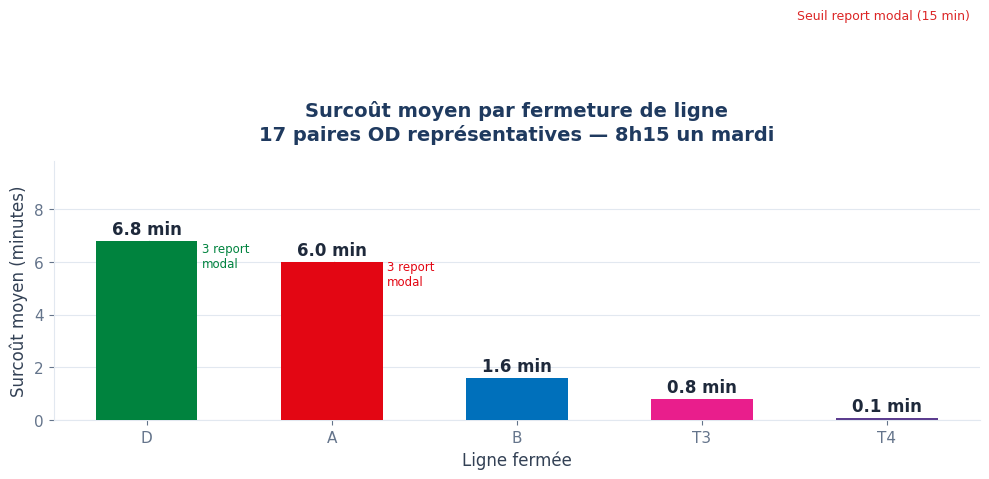

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

ROUTE_COLORS_HEX = {
    "A": "#E30613", "B": "#0070BB", "C": "#F5A623", "D": "#00833E",
    "T1": "#8B008B", "T2": "#00AAAA", "T3": "#E91E8C", "T4": "#5C3D8F",
    "T5": "#009B77", "T6": "#D4AC0D", "T7": "#C0392B",
}

# ─── DONNÉES DEPUIS df_impact ─────────────────────────────────────────────────
df_plot = df_impact[df_impact["temps_perdu_moy_min"] > 0].copy()

lignes  = df_plot["ligne"].tolist()
valeurs = df_plot["temps_perdu_moy_min"].tolist()
colors  = [ROUTE_COLORS_HEX.get(l, "#94A3B8") for l in lignes]

# ─── FIGURE ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

bars = ax.bar(lignes, valeurs, color=colors, width=0.55, zorder=3)

for bar, val in zip(bars, valeurs):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{val:.1f} min",
        ha="center", va="bottom",
        fontsize=12, fontweight="bold", color="#1E293B"
    )

ax.axhline(y=15, color="#DC2626", linewidth=1.2, linestyle="--", alpha=0.6, zorder=2)
ax.text(len(lignes) - 0.55, 15.2, "Seuil report modal (15 min)",
        fontsize=9, color="#DC2626", ha="right")

ax.set_ylim(0, max(valeurs) * 1.3 + 1)
ax.set_ylabel("Surcoût moyen (minutes)", fontsize=12, color="#334155")
ax.set_xlabel("Ligne fermée", fontsize=12, color="#334155")
ax.set_title(
    "Surcoût moyen par fermeture de ligne\n17 paires OD représentatives — 8h15 un mardi",
    fontsize=14, fontweight="bold", color="#1F3A5F", pad=15
)

ax.yaxis.grid(True, color="#E2E8F0", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#E2E8F0")
ax.spines["bottom"].set_color("#E2E8F0")
ax.tick_params(colors="#64748B", labelsize=11)

# Annotations report modal
for i, (ligne, val) in enumerate(zip(lignes, valeurs)):
    nb_report = df_plot[df_plot["ligne"] == ligne]["nb_report_modal"].values[0]
    nb_impact = df_plot[df_plot["ligne"] == ligne]["nb_impactes"].values[0]
    if nb_report > 0:
        ax.annotate(
            f"{nb_report} report\nmodal",
            xy=(i, val), xytext=(i + 0.3, val - val * 0.15),
            fontsize=8.5, color=ROUTE_COLORS_HEX.get(ligne, "#333"),
            arrowprops=dict(arrowstyle="-", color=ROUTE_COLORS_HEX.get(ligne, "#333"), lw=0.8),
        )

plt.tight_layout()
plt.savefig("impact_fermeture_lignes.png", dpi=150, bbox_inches="tight")
plt.show()

Graphe affiché : 144 stations, 159 arêtes


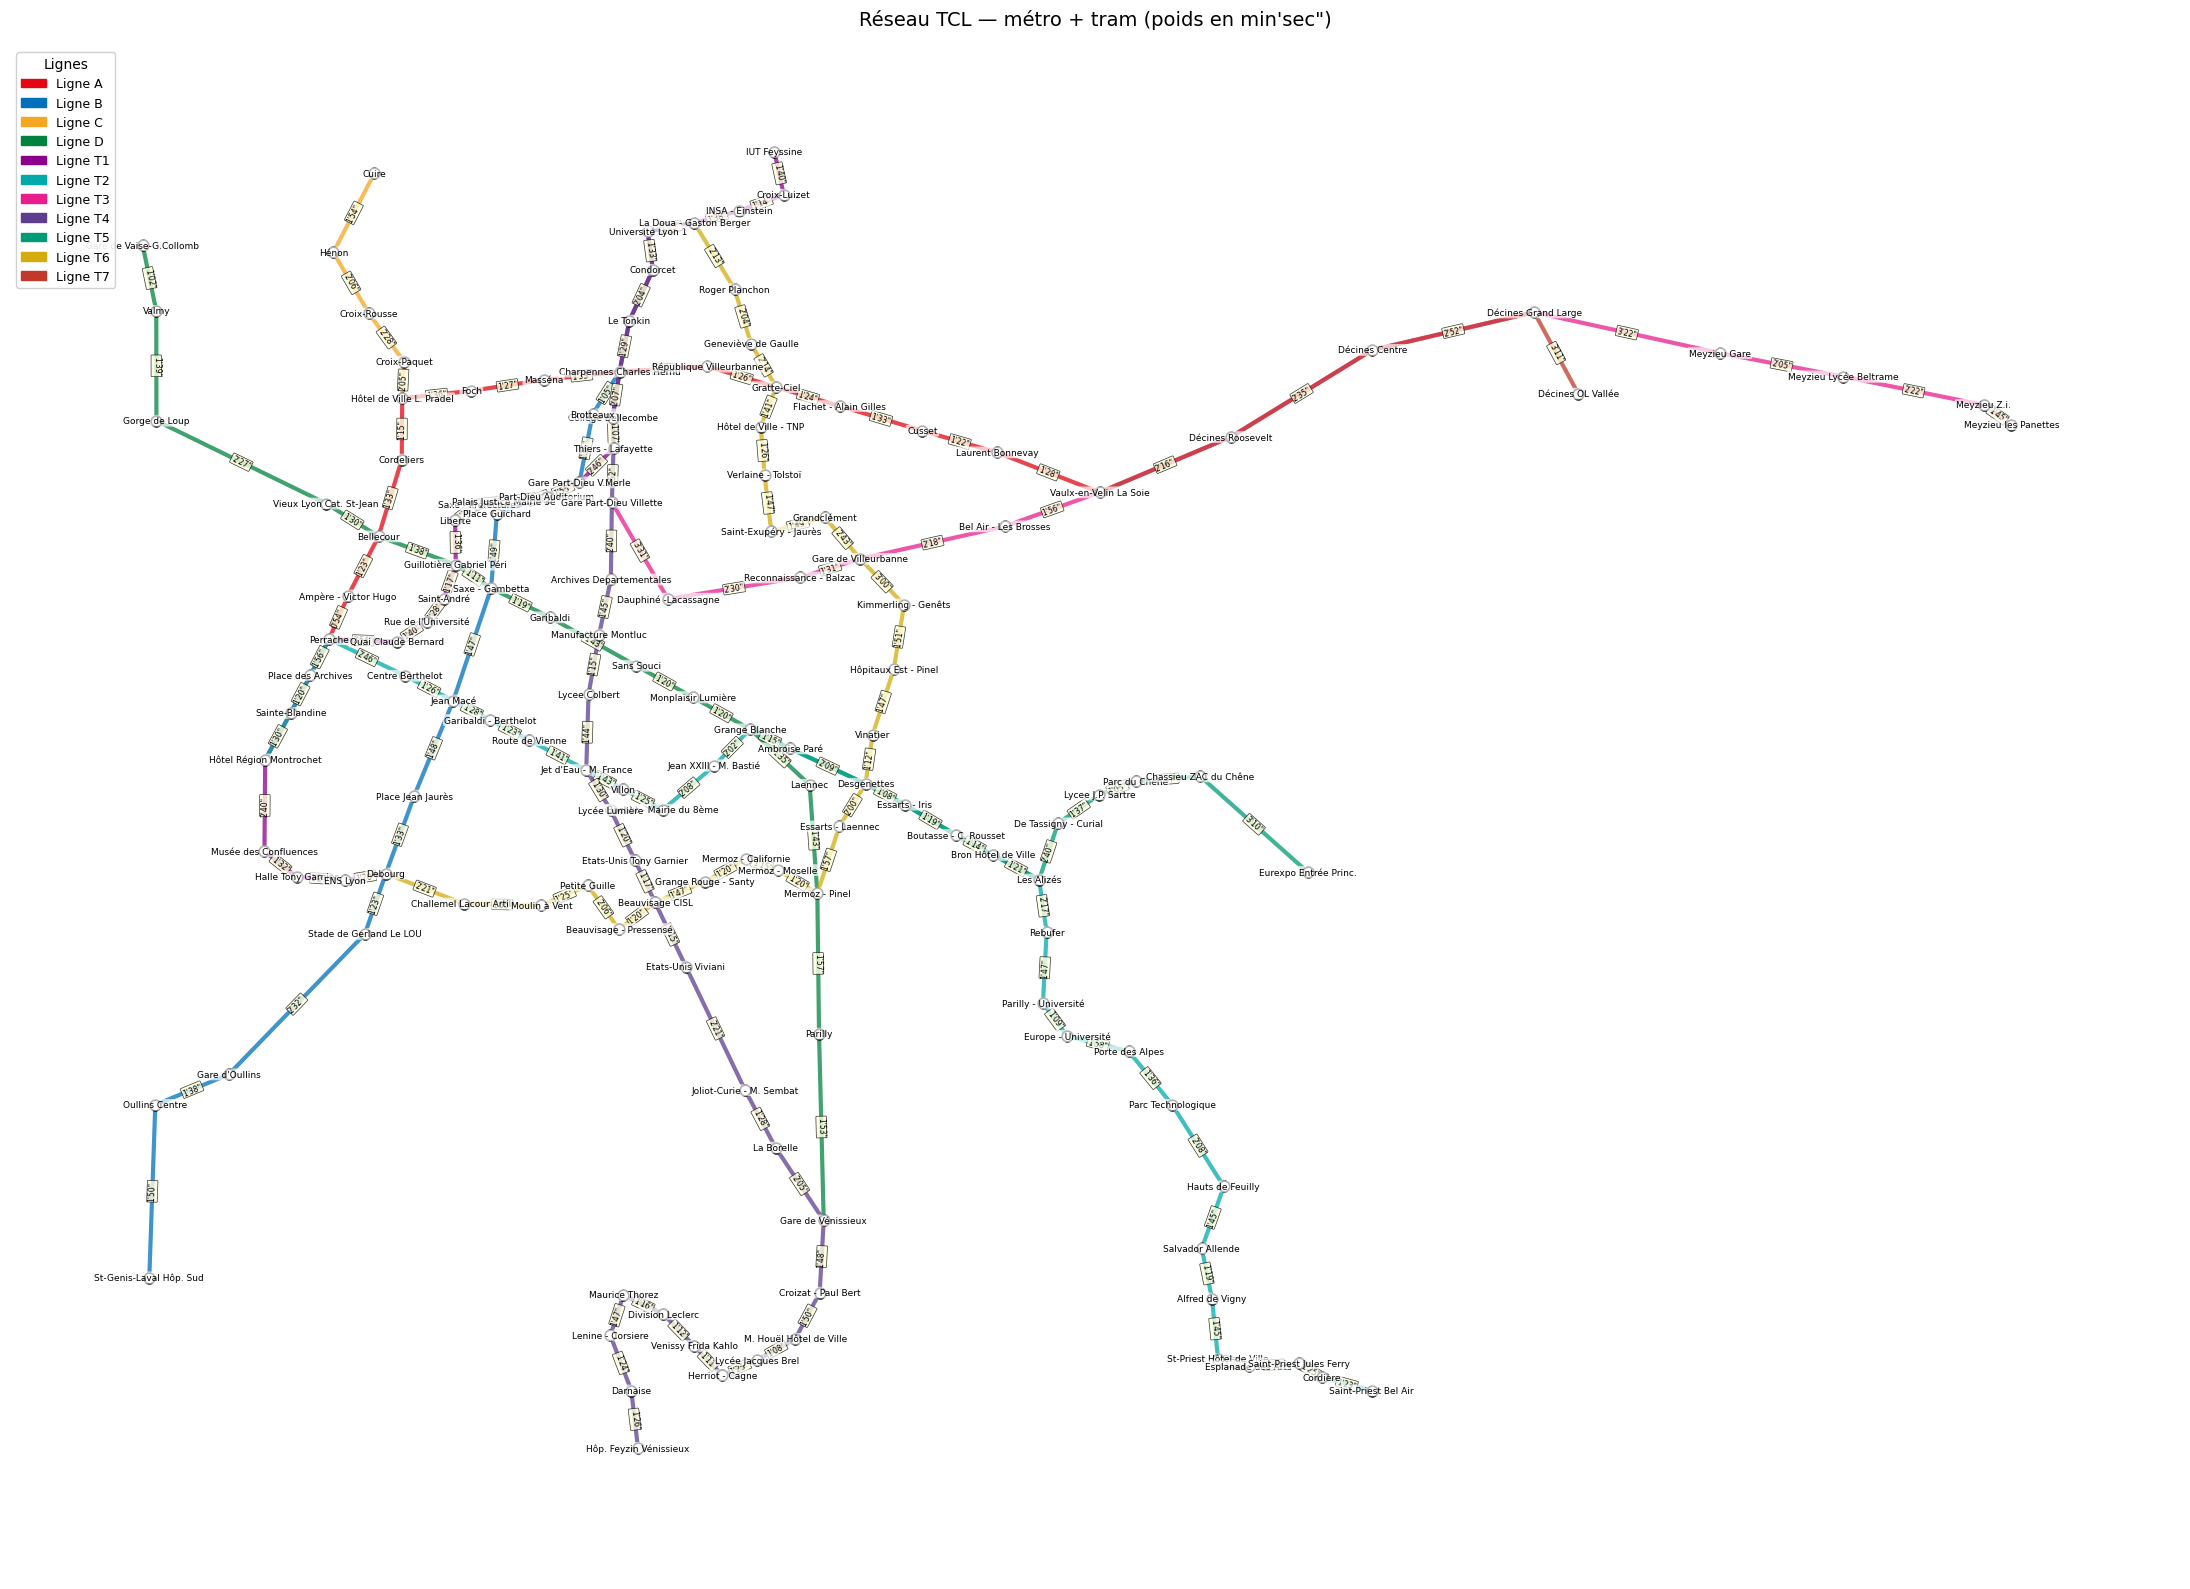

Graphe sauvegardé dans graphe_TCL_poids.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ─── COULEURS PAR LIGNE ────────────────────────────────────────────────────────
ROUTE_COLORS = {
    "A":  "#E30613",   # rouge
    "B":  "#0070BB",   # bleu
    "C":  "#F5A623",   # orange
    "D":  "#00833E",   # vert
    "T1": "#8B008B",   # violet
    "T2": "#00AAAA",   # cyan
    "T3": "#E91E8C",   # rose
    "T4": "#5C3D8F",   # violet foncé
    "T5": "#009B77",   # vert sapin
    "T6": "#D4AC0D",   # or
    "T7": "#C0392B",   # rouge foncé
}

LIGNES_EXCLUES = {"RX", "TS"}

# ─── GRAPHE FILTRÉ ─────────────────────────────────────────────────────────────
# On construit un sous-graphe sans les lignes exclues
G_affichage = G2_weighted.copy()
edges_to_remove = []
for u, v, d in G_affichage.edges(data=True):
    routes_filtrees = d.get("routes", set()) - LIGNES_EXCLUES
    if not routes_filtrees:
        edges_to_remove.append((u, v))
    else:
        G_affichage[u][v]["routes"] = routes_filtrees
G_affichage.remove_edges_from(edges_to_remove)
noeuds_isoles = [n for n, deg in G_affichage.degree() if deg == 0]
G_affichage.remove_nodes_from(noeuds_isoles)

print(f"Graphe affiché : {G_affichage.number_of_nodes()} stations, {G_affichage.number_of_edges()} arêtes")

# ─── POSITIONS GPS ─────────────────────────────────────────────────────────────
pos = {node: (data["lon"], data["lat"])
       for node, data in G_affichage.nodes(data=True)}

# ─── FIGURE ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(22, 16))

# Arêtes : une couleur par ligne, tracées séparément avec un léger offset
#          pour les tronçons partagés (T1+T4 par exemple)
lignes_presentes = set()
for u, v, d in G_affichage.edges(data=True):
    lignes_presentes |= d.get("routes", set())

for route_id in sorted(lignes_presentes):
    edges = [(u, v) for u, v, d in G_affichage.edges(data=True)
             if route_id in d.get("routes", set())]
    color = ROUTE_COLORS.get(route_id, "#999999")
    nx.draw_networkx_edges(
        G_affichage, pos, ax=ax,
        edgelist=edges,
        edge_color=color,
        width=3,
        alpha=0.75,
        arrows=False,
    )

# Nœuds
nx.draw_networkx_nodes(
    G_affichage, pos, ax=ax,
    node_size=60,
    node_color="white",
    edgecolors="black",
    linewidths=1.2,
)

# Labels des stations (décalés pour ne pas chevaucher les nœuds)
labels = {node: data["name"] for node, data in G_affichage.nodes(data=True)}
nx.draw_networkx_labels(
    G_affichage, pos, labels, ax=ax,
    font_size=6.5,
    font_family="sans-serif",
    bbox=dict(boxstyle="round,pad=0.15", fc="white", alpha=0.7, linewidth=0),
)

# Poids sur les arêtes (format "Xm Ys")
def fmt_weight(s):
    s = int(s); m, sec = divmod(s, 60)
    return f"{m}'{sec:02d}\""

edge_labels = {
    (u, v): fmt_weight(d["weight"])
    for u, v, d in G_affichage.edges(data=True)
    if "weight" in d
}
nx.draw_networkx_edge_labels(
    G_affichage, pos, edge_labels=edge_labels, ax=ax,
    font_size=5.5,
    label_pos=0.5,
    bbox=dict(boxstyle="round,pad=0.1", fc="lightyellow", alpha=0.8, linewidth=0.5),
)

# ─── LÉGENDE ──────────────────────────────────────────────────────────────────
patches = [
    mpatches.Patch(color=ROUTE_COLORS[l], label=f"Ligne {l}")
    for l in sorted(lignes_presentes)
    if l in ROUTE_COLORS
]
ax.legend(handles=patches, loc="upper left", fontsize=9,
          framealpha=0.9, title="Lignes", title_fontsize=10)

ax.set_title("Réseau TCL — métro + tram (poids en min'sec\")", fontsize=14, pad=15)
ax.axis("off")
plt.tight_layout()
plt.savefig("graphe_TCL_poids.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graphe sauvegardé dans graphe_TCL_poids.png")

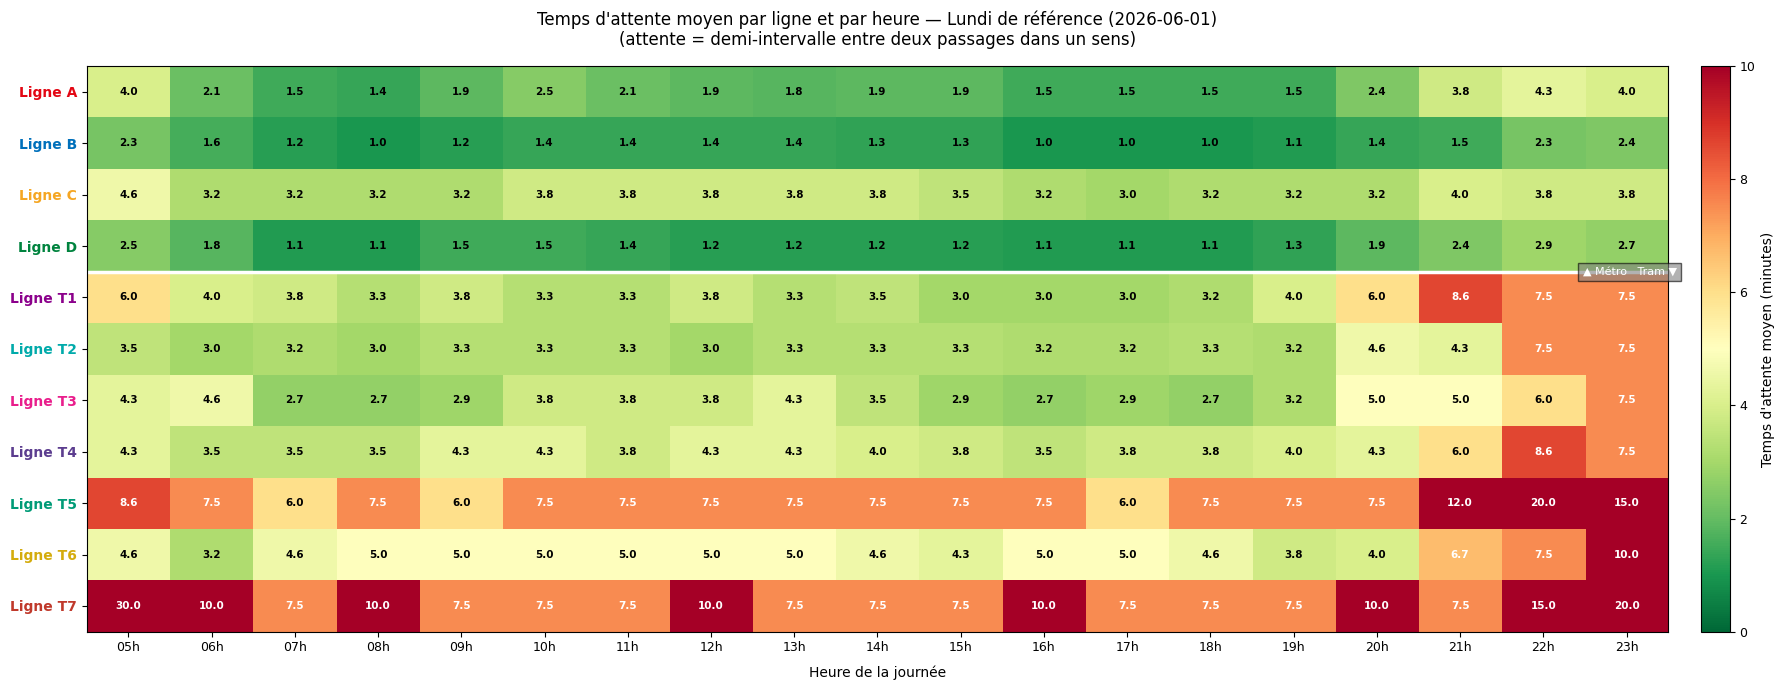

Heatmap sauvegardée dans heatmap_attentes.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# ─── DONNÉES ──────────────────────────────────────────────────────────────────
lignes_ordre = ["A", "B", "C", "D", "T1", "T2", "T3", "T4", "T5", "T6", "T7"]
heures       = list(range(5, 24))   # 5h → 23h

# Construction de la matrice (lignes x heures)
matrice = []
for ligne in lignes_ordre:
    row = []
    for h in heures:
        w = avg_wait.get((ligne, h))
        row.append(round(w / 60, 1) if w else None)   # en minutes, None si pas de service
    matrice.append(row)

matrice_np = np.array(
    [[v if v is not None else np.nan for v in row] for row in matrice],
    dtype=float
)

# ─── FIGURE ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 7))

# Colormap : vert (faible attente) → rouge (longue attente)
cmap = plt.cm.RdYlGn_r
cmap.set_bad(color="#DDDDDD")   # gris pour les créneaux sans service

im = ax.imshow(matrice_np, cmap=cmap, aspect="auto", vmin=0, vmax=10)

# ─── AXES ─────────────────────────────────────────────────────────────────────
ax.set_xticks(range(len(heures)))
ax.set_xticklabels([f"{h:02d}h" for h in heures], fontsize=9)
ax.set_yticks(range(len(lignes_ordre)))
ax.set_yticklabels([f"Ligne {l}" for l in lignes_ordre], fontsize=10, fontweight="bold")

# Couleurs des labels Y selon la ligne
ROUTE_COLORS = {
    "A": "#E30613", "B": "#0070BB", "C": "#F5A623", "D": "#00833E",
    "T1": "#8B008B", "T2": "#00AAAA", "T3": "#E91E8C", "T4": "#5C3D8F",
    "T5": "#009B77", "T6": "#D4AC0D", "T7": "#C0392B",
}
for i, label in enumerate(ax.get_yticklabels()):
    ligne = lignes_ordre[i]
    label.set_color(ROUTE_COLORS.get(ligne, "black"))

# ─── VALEURS DANS LES CELLULES ────────────────────────────────────────────────
for i, row in enumerate(matrice):
    for j, val in enumerate(row):
        if val is None:
            ax.text(j, i, "—", ha="center", va="center",
                    fontsize=7.5, color="#888888")
        else:
            # Texte blanc si fond foncé, noir sinon
            norm_val = val / 10
            brightness = 0.299 * 0.8 + 0.587 * (1 - norm_val) * 0.8 + 0.114 * 0.2
            txt_color  = "white" if norm_val > 0.6 else "black"
            ax.text(j, i, f"{val:.1f}", ha="center", va="center",
                    fontsize=7.5, color=txt_color, fontweight="bold")

# ─── COLORBAR ─────────────────────────────────────────────────────────────────
cbar = fig.colorbar(im, ax=ax, orientation="vertical", pad=0.02, fraction=0.025)
cbar.set_label("Temps d'attente moyen (minutes)", fontsize=10)
cbar.ax.tick_params(labelsize=9)

# ─── TITRES ET MISE EN PAGE ───────────────────────────────────────────────────
ax.set_title(
    "Temps d'attente moyen par ligne et par heure — Lundi de référence (2026-06-01)\n"
    "(attente = demi-intervalle entre deux passages dans un sens)",
    fontsize=12, pad=15
)
ax.set_xlabel("Heure de la journée", fontsize=10, labelpad=8)

# Séparateur visuel entre métro et tram
ax.axhline(y=3.5, color="white", linewidth=2.5)
ax.text(len(heures) - 0.4, 3.5, "▲ Métro   Tram ▼",
        ha="right", va="center", fontsize=8, color="white",
        bbox=dict(fc="gray", alpha=0.6, pad=3))

plt.tight_layout()
plt.savefig("heatmap_attentes.png", dpi=150, bbox_inches="tight")
plt.show()
print("Heatmap sauvegardée dans heatmap_attentes.png")